C:\Users\danielliu\AppData\Local\Temp\ipykernel_29984\1784792915.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  xy_ref = pd.read_csv(xy_file_ref, delim_whitespace=True, names=['2theta', 'intensity'], comment='#', nrows=600)
  File "c:\Users\danielliu\Documents\git-local\gaddsconverter\gadds.py", line 104, in rowcol_to_angles
    nX, nY = self.image.dim1, self.image.dim2
  File "c:\Users\danielliu\Documents\git-local\gaddsconverter\gadds.py", line 104, in rowcol_to_angles
    nX, nY = self.image.dim1, self.image.dim2


Info: 1281901 grid points have overlapping detector pixels (max 6 pixels per grid point)


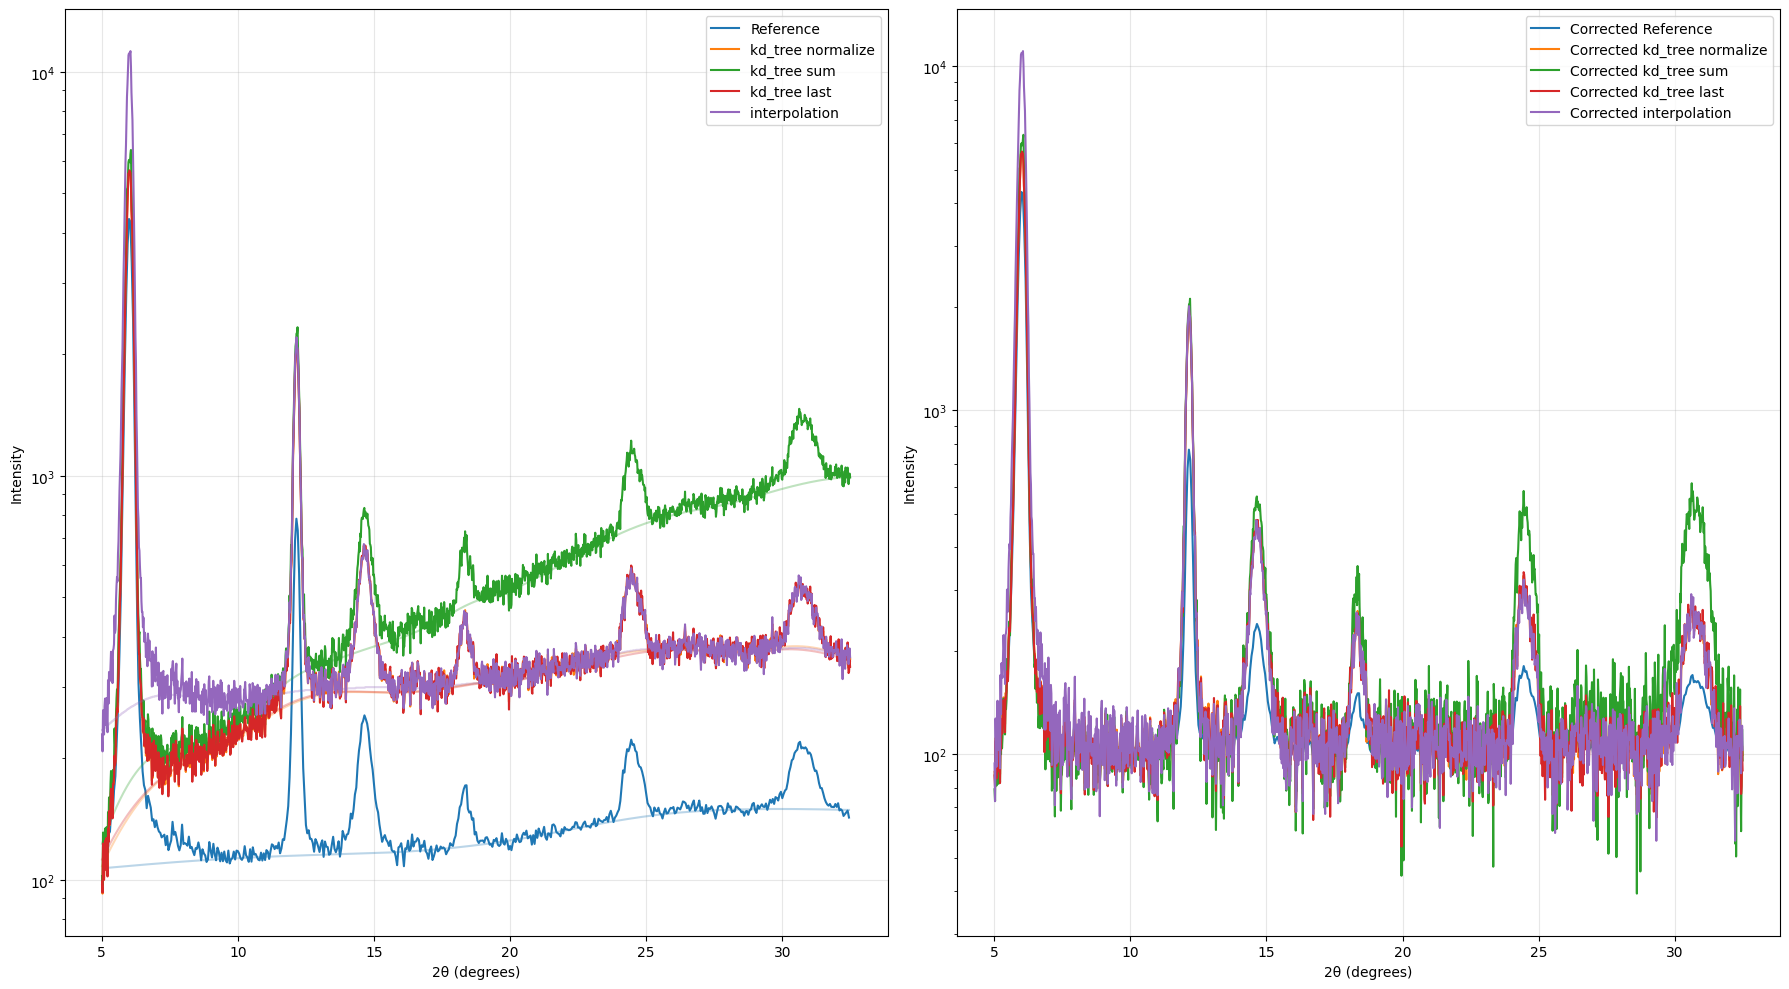

In [1]:
from gadds import AreaDetectorImage
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from package.analysis_utils import correct_baseline

xy_file_ref = (
    r"G:\My Drive\LPS\20250904_LPS_pre_5\XRD_test\20250905_LPS_pre5_1\LPS_pre5_1_A01.xy"
)

xy_ref = pd.read_csv(
    xy_file_ref,
    delim_whitespace=True,
    names=["2theta", "intensity"],
    comment="#",
    nrows=600,
)
xy_ref = xy_ref[(xy_ref["2theta"] > 5) & (xy_ref["2theta"] < 32.5)]

# Load and convert data
gfrm_file = r"G:\My Drive\LPS\20250904_LPS_pre_5\XRD_test\20250905_LPS_pre5_1\LPS_pre5_1_A01_000.gfrm"
area_detector = AreaDetectorImage(gfrm_file)
# Compare the three methods
methods = [
    {"method": "kd_tree", "overlap_method": "normalize"},
    {"method": "kd_tree", "overlap_method": "sum"},
    {"method": "kd_tree", "overlap_method": "last"},
    {"method": "interpolation"},
]

prominence = 100
height = None
distance = 5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

line = ax1.plot(xy_ref["2theta"], xy_ref["intensity"], label="Reference")
corrected_intensity, (calc_baseline, _) = correct_baseline(
    xy_ref["2theta"], xy_ref["intensity"], offset=100
)
ax1.plot(xy_ref["2theta"], calc_baseline, color=line[0].get_color(), alpha=0.3)
ax2.plot(xy_ref["2theta"], corrected_intensity, label="Corrected Reference")

for method in methods:
    area_detector.convert(**method)
    (twoth_values, intensity), *_ = area_detector.integrate_2theta()
    line = ax1.plot(
        twoth_values,
        intensity,
        label=f"{method['method']} {method.get('overlap_method', '')}",
    )
    corrected_intensity, (calc_baseline, _) = correct_baseline(
        twoth_values, intensity, offset=100
    )
    ax1.plot(twoth_values, calc_baseline, color=line[0].get_color(), alpha=0.3)
    ax2.plot(
        twoth_values,
        corrected_intensity,
        label=f"Corrected {method['method']} {method.get('overlap_method', '')}",
    )

for ax in (ax1, ax2):
    ax.set_xlabel("2θ (degrees)")
    ax.set_ylabel("Intensity")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend()


plt.tight_layout()
plt.show()

# GADDS Integration Methods: Bin Method vs Normalized Bin Method

According to the GADDS 8.7 documentation, there are several methods for converting frame images into raw spectra when performing chi integration in conic regions to produce F(2θ) data:

## Available Integration Methods:
1. **Sum pixels** (Method 0)
2. **Average pixel** (Method 1) 
3. **Arc Length** (Method 2) - "quick and dirty"
4. **Solid Angle** (Method 3)
5. **Bin Method** (Method 4)
6. **Normalized Bin Method** (Method 5) - **preferred method**

Methods 0-3 are described as "quick and dirty" methods, while the **bin method produces the most accurate results** with:
- Narrower profiles (FWHMs)
- Smoother spectra  
- Improved relative intensities across the spectra

## How the Bin Method Works

The bin method distributes pixel intensities across integration bins based on fractional area coverage.

### Bin Determination

Bins are determined by the **start, end, and step size** of the integration. For example:
- If you request range 5° to 65° in 0.5° steps:
  - First bin covers: 4.75° to 5.25°
  - Second bin covers: 5.25° to 5.75°
  - Last bin covers: 64.75° to 65.25°

The key idea: **All observed intensity within each bin range is placed into that bin.**

### Mathematical Formulas

#### Standard Bin Method (Method 4):

Each frame pixel covers one or more integration bins. The intensity of each frame pixel is divided into these integration bins using fractional area as the weighting factor:

**Equation 1 - Intensity Distribution:**
$$I_i = \sum_{n=1}^{N} I_n A_{n,i}$$

**Equation 2 - Area Conservation:**
$$1.0 = \sum_{i=1}^{M} A_{n,i}$$

Where:
- $I$ = Intensity
- $i$ = integration bin number
- $n$ = frame pixel number  
- $A$ = fractional area
- $N$ = total number of frame pixels
- $M$ = total number of integration bins

#### Normalized Bin Method (Method 5) - **Preferred**:

The normalized bin method varies from the standard bin method by **normalizing each bin by the total fractional area** of all pixels for that bin, scaled by a factor of 10:

**Equation 3 - Normalized Bin:**
$$I_i = 10 \left[ \frac{\sum_{n=1}^{N} I_n A_{n,i}}{\sum_{n=1}^{N} A_{n,i}} \right]$$

### Edge Pixel Handling

For computational speed, **frame pixels at the edges** of the integration region are not handled precisely:

#### Chi Integration:
- If the **center of the pixel** lies within the specified chi integration region → **entire pixel is used**
- If the pixel center is outside the region → **entire pixel is unused**
- **Limitation**: Narrow chi integration regions (less than a pixel width) should not be used

#### 2-theta Integration:
- If the **center of the pixel** lies within the specified 2-theta integration region → **entire pixel is used**
- If the pixel center is outside the region, but **any pixel corner** is inside the 2-theta region → **¼ of the pixel is used**
- **Advantage**: Narrow or zero width 2-theta integration regions can be used (needed for pole figure processing)

### Key Differences Between Methods:

| Method | Formula | Characteristics |
|--------|---------|----------------|
| **Bin Method** | $I_i = \sum_{n=1}^{N} I_n A_{n,i}$ | Raw intensity summation weighted by fractional area |
| **Normalized Bin** | $I_i = 10 \left[ \frac{\sum_{n=1}^{N} I_n A_{n,i}}{\sum_{n=1}^{N} A_{n,i}} \right]$ | **Preferred method** - normalizes by total fractional area, scaled by 10 |

The normalization in Method 5 accounts for varying pixel coverage across different bins, providing more accurate relative intensities and smoother spectra.

In [2]:
# Implementation of GADDS Bin Method and Normalized Bin Integration
from webbrowser import get
import numpy as np
import matplotlib.pyplot as plt
from gadds import AreaDetectorImage


def chi_integration_bin_method(
    area_detector,
    twotheta_start=5.0,
    twotheta_end=35.0,
    twotheta_step=0.05,
    chi_start=None,
    chi_end=None,
    method="normalized_bin",
    verbose=True,
):
    """
    Perform chi integration using GADDS bin method or normalized bin method.

    This implements the exact formulas from GADDS 8.7 documentation:
    - Standard Bin Method: I_i = Σ(I_n * A_n,i)
    - Normalized Bin Method: I_i = 10 * [Σ(I_n * A_n,i) / Σ(A_n,i)]

    Parameters:
    -----------
    area_detector : AreaDetectorImage
        The loaded GFRM data with coordinate transformation capabilities
    twotheta_start, twotheta_end : float
        2theta range in degrees
    twotheta_step : float
        2theta step size in degrees
    chi_start, chi_end : float or None
        Chi (gamma) range in degrees. If None, uses detector limits.
    method : str
        'bin' for standard bin method, 'normalized_bin' for normalized bin method
    verbose : bool
        Print processing information

    Returns:
    --------
    twotheta_values : np.array
        2theta bin centers in degrees
    intensities : np.array
        Integrated intensities using specified method
    """

    # If chi limits are not specified, use detector limits (like gadds.py)

    if chi_start is None or chi_end is None:
        gamma_min_deg = np.rad2deg(area_detector.limits[2])
        gamma_max_deg = np.rad2deg(area_detector.limits[3])
        if chi_start is None:
            chi_start = gamma_min_deg
        if chi_end is None:
            chi_end = gamma_max_deg

    else:
        if chi_start < np.rad2deg(area_detector.limits[2]) or chi_start > np.rad2deg(
            area_detector.limits[3]
        ):
            raise ValueError(
                f"chi_start {chi_start}° is out of detector gamma limits [{np.rad2deg(area_detector.limits[2]):.1f}°, {np.rad2deg(area_detector.limits[3]):.1f}°]"
            )
        if chi_end < np.rad2deg(area_detector.limits[2]) or chi_end > np.rad2deg(
            area_detector.limits[3]
        ):
            raise ValueError(
                f"chi_end {chi_end}° is out of detector gamma limits [{np.rad2deg(area_detector.limits[2]):.1f}°, {np.rad2deg(area_detector.limits[3]):.1f}°]"
            )
        if chi_start > chi_end:
            raise ValueError("chi_start should be smaller than chi_end")

    if verbose:
        print(f"Starting {method} integration...")
        print(
            f"2θ range: {twotheta_start}° to {twotheta_end}° with {twotheta_step}° steps"
        )
        print(f"χ (gamma) range: {chi_start:.1f}° to {chi_end:.1f}°")
        print(
            f"Detector gamma limits: {np.rad2deg(area_detector.limits[2]):.1f}° to {np.rad2deg(area_detector.limits[3]):.1f}°"
        )

    # Get image dimensions and create pixel coordinate arrays
    image_data = area_detector.image.data
    height, width = image_data.shape

    if verbose:
        print(f"Image dimensions: {height} x {width}")
        print(f"Total pixels: {height * width:,}")

    # Create bin structure according to GADDS documentation
    # Bins are: first bin 4.75-5.25, second bin 5.25-5.75, etc.
    num_bins = int((twotheta_end - twotheta_start) / twotheta_step) + 1
    bin_centers = np.linspace(twotheta_start, twotheta_end, num_bins)
    bin_edges = np.concatenate(
        [
            [bin_centers[0] - twotheta_step / 2],  # Left edge of first bin
            bin_centers[:-1] + twotheta_step / 2,  # Right edges become left edges
            [bin_centers[-1] + twotheta_step / 2],  # Right edge of last bin
        ]
    )

    if verbose:
        print(f"Created {num_bins} bins")
        print(f"Bin edges: {bin_edges[0]:.3f} to {bin_edges[-1]:.3f}°")

    # Initialize integration arrays
    integrated_intensities = np.zeros(num_bins)
    total_fractional_areas = np.zeros(num_bins)  # For normalized bin method

    rows, cols = np.mgrid[0:height, 0:width]
    rows_flat = rows.flatten()
    cols_flat = cols.flatten()
    intensities_flat = image_data.flatten()

    # Filter pixels within chi integration range
    twotheta_deg, gamma_deg = np.rad2deg(
        area_detector.rowcol_to_angles(rows_flat, cols_flat)
    )
    chi_mask = (gamma_deg >= chi_start) & (gamma_deg <= chi_end)
    rows_flat = rows_flat[chi_mask]
    cols_flat = cols_flat[chi_mask]
    intensities_flat = intensities_flat[chi_mask]
    twotheta_deg = twotheta_deg[chi_mask]
    gamma_deg = gamma_deg[chi_mask]

    # Remove pixels outside twotheta range
    valid_twotheta_mask = (twotheta_deg >= twotheta_start) & (
        twotheta_deg <= twotheta_end
    )
    rows_flat = rows_flat[valid_twotheta_mask]
    cols_flat = cols_flat[valid_twotheta_mask]
    twotheta_deg = twotheta_deg[valid_twotheta_mask]
    twotheta_left_edge_deg, _ = np.rad2deg(
        area_detector.rowcol_to_angles(((rows_flat - 1) + rows_flat) / 2, cols_flat)
    )
    twotheta_right_edge_deg, _ = np.rad2deg(
        area_detector.rowcol_to_angles(((rows_flat + 1) + rows_flat) / 2, cols_flat)
    )
    intensities_flat = intensities_flat[valid_twotheta_mask]

    # Pixel could be either fully in one bin, or straddling multiple bins
    # Determine which pixels are fully in one bin
    bin_indices = np.digitize(twotheta_deg, bin_edges) - 1
    bin_indices_left = np.digitize(twotheta_left_edge_deg, bin_edges) - 1
    bin_indices_right = np.digitize(twotheta_right_edge_deg, bin_edges) - 1

    straddle_mask = bin_indices_left != bin_indices_right
    full_mask = ~straddle_mask

    # For pixels fully in one bin, assign full intensity
    np.add.at(
        integrated_intensities, bin_indices[full_mask], intensities_flat[full_mask]
    )
    np.add.at(total_fractional_areas, bin_indices[full_mask], 1)

    # For straddling pixels, calculate fractional areas
    straddle_pixels = intensities_flat[straddle_mask]
    straddle_cols = cols_flat[straddle_mask]
    straddle_rows = rows_flat[straddle_mask]
    twotheta_left_edge_deg = twotheta_left_edge_deg[straddle_mask]
    twotheta_right_edge_deg = twotheta_right_edge_deg[straddle_mask]

    # Get bin to pixels mapping in shape (num_bins, num_straddle_pixels)
    straddle_bins_to_pixels = np.zeros((num_bins, len(straddle_pixels)), dtype=bool)
    for i in range(num_bins):
        straddle_bins_to_pixels[i, :] = (twotheta_left_edge_deg < bin_edges[i + 1]) & (
            twotheta_right_edge_deg > bin_edges[i]
        )

    def shoelace_formula_vectorized(corners):
        """
        Apply Shoelace formula to compute areas of multiple quadrilaterals.

        Parameters:
        -----------
        corners : np.ndarray, shape (4, N, 2)
            Array where:
            - First dimension: 4 corner points of each quadrilateral
            - Second dimension: N different quadrilaterals
            - Third dimension: (x, y) coordinates

        Returns:
        --------
        areas : np.ndarray, shape (N,)
            Areas of each quadrilateral
        """

        # Extract x and y coordinates
        x = corners[:, :, 0]  # Shape: (4, N) - x coordinates
        y = corners[:, :, 1]  # Shape: (4, N) - y coordinates

        # Roll to get next vertices (wraps around: 0->1, 1->2, 2->3, 3->0)
        x_next = np.roll(x, -1, axis=0)  # Shape: (4, N)
        y_next = np.roll(y, -1, axis=0)  # Shape: (4, N)

        # Shoelace formula: sum of (x_i * y_i+1 - x_i+1 * y_i)
        cross_products = x * y_next - x_next * y  # Shape: (4, N)

        # Sum over the 4 vertices and take absolute value, divide by 2
        areas = 0.5 * np.abs(np.sum(cross_products, axis=0))  # Shape: (N,)

        return areas

    def get_fractional_areas(row, col, twotheta_left, twotheta_right):
        # Calculate the four corners of the pixel

        corners = np.stack(
            [
                area_detector.rowcol_to_angles(row - 0.5, col - 0.5),  # Top-left
                area_detector.rowcol_to_angles(row - 0.5, col + 0.5),  # Top-right
                area_detector.rowcol_to_angles(row + 0.5, col + 0.5),  # Bottom-right
                area_detector.rowcol_to_angles(row + 0.5, col - 0.5),  # Bottom-left
            ]
        )  # This creates shape (4, N, 2)

        # Convert to degrees
        corners = np.rad2deg(corners).transpose(0, 2, 1)

        # Apply Shoelace formula vectorized
        pixel_areas = shoelace_formula_vectorized(corners)

        clipped_corners = corners.copy()

        # For each pixel, find the min/max 2theta values of its corners
        pixel_twotheta_min = np.min(corners[:, :, 0], axis=0)  # Shape: (N,)
        pixel_twotheta_max = np.max(corners[:, :, 0], axis=0)  # Shape: (N,)

        # Clip the bin boundaries to the pixel's 2theta range
        clipped_left = np.maximum(twotheta_left, pixel_twotheta_min)  # Shape: (N,)
        clipped_right = np.minimum(twotheta_right, pixel_twotheta_max)  # Shape: (N,)

        # Replace the 2theta coordinates with the clipped boundaries
        # This creates a rectangle with the intersection bounds
        clipped_corners[0, :, 0] = clipped_left  # Top-left 2theta
        clipped_corners[1, :, 0] = clipped_right  # Top-right 2theta
        clipped_corners[2, :, 0] = clipped_right  # Bottom-right 2theta
        clipped_corners[3, :, 0] = clipped_left  # Bottom-left 2theta

        # Keep the original gamma coordinates unchanged
        # clipped_corners[:, :, 1] remains the same as corners[:, :, 1]

        # Calculate intersection areas
        intersection_areas = shoelace_formula_vectorized(clipped_corners)

        # Handle case where there's no intersection (clipped_left >= clipped_right)
        no_intersection = clipped_left >= clipped_right
        intersection_areas[no_intersection] = 0.0

        # Return fractional areas
        return intersection_areas / pixel_areas

    for i, pixels in enumerate(straddle_bins_to_pixels):
        if not np.any(pixels):
            continue
        fractional_areas = get_fractional_areas(
            straddle_rows[pixels], straddle_cols[pixels], bin_edges[i], bin_edges[i + 1]
        )

        np.add.at(
            integrated_intensities,
            i,
            np.sum(straddle_pixels[pixels] * fractional_areas),
        )
        np.add.at(total_fractional_areas, i, np.sum(fractional_areas))

    if verbose:
        print(f"Processed {len(rows_flat):,} pixels")
        print(f"Pixels fully in one bin: {np.sum(full_mask):,}")
        print(f"Pixels straddling multiple bins: {np.sum(straddle_mask):,}")
        print(
            f"Stradding distripution, histogram with index in number of bins: {np.histogram(np.sum(straddle_bins_to_pixels, axis=0), bins=np.arange(1, np.sum(straddle_bins_to_pixels, axis=0).max() + 2))[0]}"
        )
        print(f"Bins with data: {np.sum(total_fractional_areas > 0)}")

    # Apply method-specific processing
    if method == "normalized_bin":
        # Equation 3: I_i = 10 * [Σ(I_n * A_n,i) / Σ(A_n,i)]
        valid_bins = total_fractional_areas > 0
        integrated_intensities[valid_bins] = (
            10.0
            * integrated_intensities[valid_bins]
            / total_fractional_areas[valid_bins]
        )
        if verbose:
            print("Applied normalized bin method (Equation 3)")
    elif method == "bin":
        # Equation 1: I_i = Σ(I_n * A_n,i) - no additional processing needed
        if verbose:
            print("Applied standard bin method (Equation 1)")
    else:
        raise ValueError(f"Unknown method: {method}. Use 'bin' or 'normalized_bin'")

    return bin_centers, integrated_intensities


# Load the GFRM file and perform integration
gfrm_file = r"G:\My Drive\LPS\20250904_LPS_pre_5\XRD_test\20250905_LPS_pre5_1\LPS_pre5_1_A01_000.gfrm"
area_detector = AreaDetectorImage(gfrm_file)

print("AreaDetectorImage loaded successfully!")
print(f"Image shape: {area_detector.image.data.shape}")
print(f"Detector parameters:")
print(f"  Alpha (2θ center): {np.rad2deg(area_detector.alpha):.3f}°")
print(f"  Distance: {area_detector.distance:.2f} cm")
print(f"  Center XY: {area_detector.centerXY}")
print(f"  Density XY: {area_detector.densityXY}")
print(f"  Chi offset: {np.rad2deg(area_detector.chi):.1f}°")
print(
    f"  Gamma limits: [{np.rad2deg(area_detector.limits[2]):.1f}°, {np.rad2deg(area_detector.limits[3]):.1f}°]"
)

  File "c:\Users\danielliu\Documents\git-local\gaddsconverter\gadds.py", line 104, in rowcol_to_angles
    nX, nY = self.image.dim1, self.image.dim2
  File "c:\Users\danielliu\Documents\git-local\gaddsconverter\gadds.py", line 104, in rowcol_to_angles
    nX, nY = self.image.dim1, self.image.dim2


AreaDetectorImage loaded successfully!
Image shape: (2048, 2048)
Detector parameters:
  Alpha (2θ center): 20.000°
  Distance: 22.45 cm
  Center XY: (1003.7000122, 1022.0999756)
  Density XY: (147.0628052, 147.0628052)
  Chi offset: -90.0°
  Gamma limits: [-171.7°, -8.3°]


C:\Users\danielliu\AppData\Local\Temp\ipykernel_56616\303098748.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  xy_ref = pd.read_csv(


Reference data loaded: 600 points
2θ range: 5.000° to 34.950°

Integration parameters:
2θ: 5.0° to 35.0° in 0.05° steps
χ: Using detector limits (matching gadds.py behavior)

STANDARD BIN METHOD
Starting bin integration...
2θ range: 5.0° to 35.0° with 0.05° steps
χ (gamma) range: -171.7° to -8.3°
Detector gamma limits: -171.7° to -8.3°
Image dimensions: 2048 x 2048
Total pixels: 4,194,304
Created 601 bins
Bin edges: 4.975 to 35.025°
Processed 3,731,192 pixels
Pixels fully in one bin: 3,195,854
Pixels straddling multiple bins: 535,338
Stradding distripution, histogram with index in number of bins: [     0 266766]
Bins with data: 601
Applied standard bin method (Equation 1)

NORMALIZED BIN METHOD (PREFERRED)
Starting normalized_bin integration...
2θ range: 5.0° to 35.0° with 0.05° steps
χ (gamma) range: -171.7° to -8.3°
Detector gamma limits: -171.7° to -8.3°
Image dimensions: 2048 x 2048
Total pixels: 4,194,304
Created 601 bins
Bin edges: 4.975 to 35.025°
Processed 3,731,192 pixels
Pixe

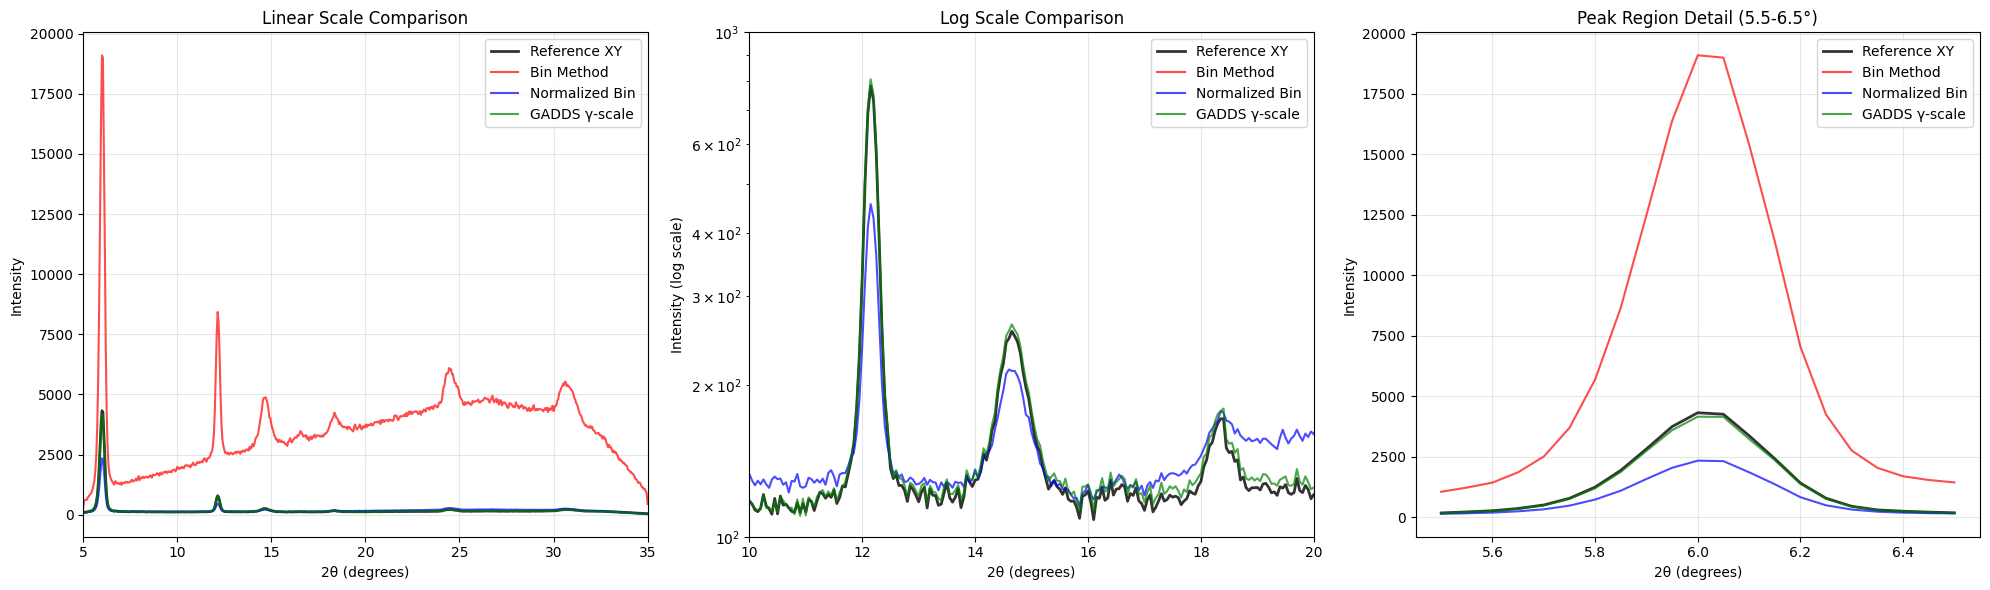


COMPARISON STATISTICS
Correlation with reference:
  Standard Bin Method:   0.7517
  Normalized Bin Method: 0.9853
  GADDS Gamma-scale:     0.9999

Peak at 2θ = 6.000°:
  Reference intensity:     4322.4
  Bin method intensity:    19100.5 (4.419x)
  Normalized bin intensity: 2341.9 (0.542x)
  GADDS gamma-scale intensity: 4160.3 (0.962x)

Integration completed successfully!
Standard Bin Method: 601 non-zero points
Normalized Bin Method: 601 non-zero points
GADDS Gamma-scale Method: 601 non-zero points

RMS Error with reference:
  Standard Bin Method:   3694.271
  Normalized Bin Method: 174.394
  GADDS Gamma-scale:     13.648

Root Relative Squared Error (RRSE) with reference:
  Standard Bin Method:   1022.56%
  Normalized Bin Method: 48.27%
  GADDS Gamma-scale:     3.78%


In [14]:
# Perform chi integration using both methods and compare with reference
import pandas as pd

# Load reference data
xy_file_ref = (
    r"G:\My Drive\LPS\20250904_LPS_pre_5\XRD_test\20250905_LPS_pre5_1\LPS_pre5_1_A01.xy"
)
xy_ref = pd.read_csv(
    xy_file_ref,
    delim_whitespace=True,
    names=["2theta", "intensity"],
    comment="#",
    nrows=600,
)
xy_ref = xy_ref[(xy_ref["2theta"] >= 5) & (xy_ref["2theta"] <= 35)]

total_intensity_ref = xy_ref["intensity"].sum()

print(f"Reference data loaded: {len(xy_ref)} points")
print(f"2θ range: {xy_ref['2theta'].min():.3f}° to {xy_ref['2theta'].max():.3f}°")

# Parameters matching the reference data
twotheta_start = 5.0
twotheta_end = 35.0
twotheta_step = 0.05

print(f"\nIntegration parameters:")
print(f"2θ: {twotheta_start}° to {twotheta_end}° in {twotheta_step}° steps")
print(f"χ: Using detector limits (matching gadds.py behavior)")

# Perform integration using both methods with detector limits (no explicit chi limits)
print("\n" + "=" * 60)
print("STANDARD BIN METHOD")
print("=" * 60)
twoth_bin, intensity_bin = chi_integration_bin_method(
    area_detector,
    twotheta_start=twotheta_start,
    twotheta_end=twotheta_end,
    twotheta_step=twotheta_step,
    # chi_start and chi_end default to None, using detector limits
    method="bin",
    verbose=True,
)

print("\n" + "=" * 60)
print("NORMALIZED BIN METHOD (PREFERRED)")
print("=" * 60)
twoth_norm, intensity_norm = chi_integration_bin_method(
    area_detector,
    twotheta_start=twotheta_start,
    twotheta_end=twotheta_end,
    twotheta_step=twotheta_step,
    # chi_start and chi_end default to None, using detector limits
    method="normalized_bin",
    verbose=True,
)

print(
    f"Normalized Bin intensity scaled to reference total intensity: {total_intensity_ref / np.sum(intensity_norm):.4f}"
)
intensity_norm *= total_intensity_ref / np.sum(intensity_norm)

# Test with GADDS-style restricted gamma range
print("\n" + "=" * 60)
print("GADDS-STYLE RESTRICTED GAMMA RANGE")
print("=" * 60)
delta_gamma = 22.5 - np.rad2deg(area_detector.alpha) * 0.2
gamma_range_degrees = [
    np.rad2deg(area_detector.chi) - delta_gamma,
    np.rad2deg(area_detector.chi) + delta_gamma,
]

print(
    f"Restricted gamma range: {gamma_range_degrees[0]:.1f}° to {gamma_range_degrees[1]:.1f}°"
)

twoth_gadds, intensity_gadds = chi_integration_bin_method(
    area_detector,
    twotheta_start=twotheta_start,
    twotheta_end=twotheta_end,
    twotheta_step=twotheta_step,
    chi_start=gamma_range_degrees[0],
    chi_end=gamma_range_degrees[1],
    method="normalized_bin",
    verbose=True,
)

print(
    f"Gadds intensity scaled to reference total intensity: {total_intensity_ref / np.sum(intensity_gadds):.4f}"
)
intensity_gadds *= total_intensity_ref / np.sum(intensity_gadds)

# Create comparison plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Linear scale comparison
ax1.plot(
    xy_ref["2theta"],
    xy_ref["intensity"],
    "k-",
    label="Reference XY",
    linewidth=2,
    alpha=0.8,
)
ax1.plot(twoth_bin, intensity_bin, "r-", label="Bin Method", alpha=0.7)
ax1.plot(twoth_norm, intensity_norm, "b-", label="Normalized Bin", alpha=0.7)
ax1.plot(twoth_gadds, intensity_gadds, "g-", label="GADDS γ-scale", alpha=0.7)
ax1.set_xlabel("2θ (degrees)")
ax1.set_ylabel("Intensity")
ax1.set_title("Linear Scale Comparison")
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim(5, 35)

# Plot 2: Log scale comparison
ax2.semilogy(
    xy_ref["2theta"],
    xy_ref["intensity"],
    "k-",
    label="Reference XY",
    linewidth=2,
    alpha=0.8,
)
ax2.semilogy(
    twoth_bin, intensity_bin[intensity_bin > 0], "r-", label="Bin Method", alpha=0.7
)
ax2.semilogy(
    twoth_norm,
    intensity_norm[intensity_norm > 0],
    "b-",
    label="Normalized Bin",
    alpha=0.7,
)
if np.any(intensity_gadds > 0):
    ax2.semilogy(
        twoth_gadds,
        intensity_gadds[intensity_gadds > 0],
        "g-",
        label="GADDS γ-scale",
        alpha=0.7,
    )
ax2.set_xlabel("2θ (degrees)")
ax2.set_ylabel("Intensity (log scale)")
ax2.set_title("Log Scale Comparison")
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_xlim(10, 20)
ax2.set_ylim(100, 1000)

# Plot 3: Focus on peak region
peak_range = (xy_ref["2theta"] >= 5.5) & (xy_ref["2theta"] <= 6.5)
twoth_range = (twoth_norm >= 5.5) & (twoth_norm <= 6.5)

ax3.plot(
    xy_ref["2theta"][peak_range],
    xy_ref["intensity"][peak_range],
    "k-",
    label="Reference XY",
    linewidth=2,
    alpha=0.8,
)
ax3.plot(
    twoth_bin[twoth_range],
    intensity_bin[twoth_range],
    "r-",
    label="Bin Method",
    alpha=0.7,
)
ax3.plot(
    twoth_norm[twoth_range],
    intensity_norm[twoth_range],
    "b-",
    label="Normalized Bin",
    alpha=0.7,
)
ax3.plot(
    twoth_gadds[twoth_range],
    intensity_gadds[twoth_range],
    "g-",
    label="GADDS γ-scale",
    alpha=0.7,
)
ax3.set_xlabel("2θ (degrees)")
ax3.set_ylabel("Intensity")
ax3.set_title("Peak Region Detail (5.5-6.5°)")
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

# Calculate and print comparison statistics
print("\n" + "=" * 60)
print("COMPARISON STATISTICS")
print("=" * 60)

# Interpolate our results to reference 2theta points for direct comparison
from scipy.interpolate import interp1d

# Only compare where both datasets have data
common_mask = (xy_ref["2theta"] >= twoth_norm.min()) & (
    xy_ref["2theta"] <= twoth_norm.max()
)
ref_subset = xy_ref[common_mask]

if len(ref_subset) > 0:
    # Interpolate our results to reference points
    interp_bin = interp1d(twoth_bin, intensity_bin, bounds_error=False, fill_value=0)
    interp_norm = interp1d(twoth_norm, intensity_norm, bounds_error=False, fill_value=0)
    interp_gadds = interp1d(
        twoth_gadds, intensity_gadds, bounds_error=False, fill_value=0
    )

    bin_interp = interp_bin(ref_subset["2theta"])
    norm_interp = interp_norm(ref_subset["2theta"])
    gadds_interp = interp_gadds(ref_subset["2theta"])

    # Calculate correlation coefficients
    valid_mask = (bin_interp > 0) & (norm_interp > 0) & (ref_subset["intensity"] > 0)

    if np.sum(valid_mask) > 10:
        corr_bin = np.corrcoef(
            ref_subset["intensity"][valid_mask], bin_interp[valid_mask]
        )[0, 1]
        corr_norm = np.corrcoef(
            ref_subset["intensity"][valid_mask], norm_interp[valid_mask]
        )[0, 1]
        corr_gadds = np.corrcoef(
            ref_subset["intensity"][valid_mask], gadds_interp[valid_mask]
        )[0, 1]

        print(f"Correlation with reference:")
        print(f"  Standard Bin Method:   {corr_bin:.4f}")
        print(f"  Normalized Bin Method: {corr_norm:.4f}")
        print(f"  GADDS Gamma-scale:     {corr_gadds:.4f}")

        # Peak intensity comparison
        ref_peak_idx = np.argmax(ref_subset["intensity"])
        ref_peak_2th = ref_subset["2theta"].iloc[ref_peak_idx]
        ref_peak_int = ref_subset["intensity"].iloc[ref_peak_idx]

        bin_peak_int = interp_bin(ref_peak_2th)
        norm_peak_int = interp_norm(ref_peak_2th)
        gadds_peak_int = interp_gadds(ref_peak_2th)

        print(f"\nPeak at 2θ = {ref_peak_2th:.3f}°:")
        print(f"  Reference intensity:     {ref_peak_int:.1f}")
        print(
            f"  Bin method intensity:    {bin_peak_int:.1f} ({bin_peak_int / ref_peak_int:.3f}x)"
        )
        print(
            f"  Normalized bin intensity: {norm_peak_int:.1f} ({norm_peak_int / ref_peak_int:.3f}x)"
        )
        print(
            f"  GADDS gamma-scale intensity: {gadds_peak_int:.1f} ({gadds_peak_int / ref_peak_int:.3f}x)"
        )

print(f"\nIntegration completed successfully!")
print(f"Standard Bin Method: {np.sum(intensity_bin > 0)} non-zero points")
print(f"Normalized Bin Method: {np.sum(intensity_norm > 0)} non-zero points")
print(f"GADDS Gamma-scale Method: {np.sum(intensity_gadds > 0)} non-zero points")


# Calulate RMS error between ref and our methods
def calculate_rms_error(x1, y1, x2, y2):
    from scipy.interpolate import interp1d

    # Interpolate y2 to x1 points
    interp_func = interp1d(x2, y2, bounds_error=False, fill_value=0)
    y2_interp = interp_func(x1)

    # Only consider points where both have data
    valid_mask = (y1 > 0) & (y2_interp > 0)
    if np.sum(valid_mask) == 0:
        return np.nan

    rms_error = np.sqrt(np.mean((y1[valid_mask] - y2_interp[valid_mask]) ** 2))
    return rms_error


def calculate_rrse(x1, y1, x2, y2):
    """
    Calculate Root Relative Squared Error (RRSE) between two datasets.

    RRSE = sqrt(Σ(y1 - y2)²) / sqrt(Σ(y1 - mean(y1))²) * 100%

    This normalizes the RMSE by the standard deviation of the reference data,
    making it a percentage that's easier to interpret across different scales.

    Parameters:
    -----------
    x1, y1 : reference data (x, y coordinates)
    x2, y2 : comparison data (x, y coordinates)

    Returns:
    --------
    rrse : float
        Root Relative Squared Error as a percentage
    """
    from scipy.interpolate import interp1d

    # Interpolate y2 to x1 points
    interp_func = interp1d(x2, y2, bounds_error=False, fill_value=0)
    y2_interp = interp_func(x1)

    # Only consider points where both have data
    valid_mask = (y1 > 0) & (y2_interp > 0)
    if np.sum(valid_mask) == 0:
        return np.nan

    y1_valid = y1[valid_mask]
    y2_valid = y2_interp[valid_mask]

    # Calculate RRSE
    numerator = np.sqrt(np.mean((y1_valid - y2_valid) ** 2))
    denominator = np.sqrt(np.mean((y1_valid - np.mean(y1_valid)) ** 2))

    if denominator == 0:
        return np.nan

    rrse = (numerator / denominator) * 100.0
    return rrse


rms_bin = calculate_rms_error(
    xy_ref["2theta"].values, xy_ref["intensity"].values, twoth_bin, intensity_bin
)
rms_norm = calculate_rms_error(
    xy_ref["2theta"].values, xy_ref["intensity"].values, twoth_norm, intensity_norm
)
rms_gadds = calculate_rms_error(
    xy_ref["2theta"].values, xy_ref["intensity"].values, twoth_gadds, intensity_gadds
)

rrse_bin = calculate_rrse(
    xy_ref["2theta"].values, xy_ref["intensity"].values, twoth_bin, intensity_bin
)
rrse_norm = calculate_rrse(
    xy_ref["2theta"].values, xy_ref["intensity"].values, twoth_norm, intensity_norm
)
rrse_gadds = calculate_rrse(
    xy_ref["2theta"].values, xy_ref["intensity"].values, twoth_gadds, intensity_gadds
)

print(f"\nRMS Error with reference:")
print(f"  Standard Bin Method:   {rms_bin:.3f}")
print(f"  Normalized Bin Method: {rms_norm:.3f}")
print(f"  GADDS Gamma-scale:     {rms_gadds:.3f}")

print(f"\nRoot Relative Squared Error (RRSE) with reference:")
print(f"  Standard Bin Method:   {rrse_bin:.2f}%")
print(f"  Normalized Bin Method: {rrse_norm:.2f}%")
print(f"  GADDS Gamma-scale:     {rrse_gadds:.2f}%")


INVESTIGATING DETECTOR GAMMA LIMITS AND CHI OFFSET
Detector limits (radians): (np.float64(0.042993624535882104), np.float64(0.6975323349012806), np.float64(-2.9975358936217753), np.float64(-0.14472455588297184))
Detector limits (degrees): 2θ=[2.5, 40.0], γ=[-171.7, -8.3]
Chi offset: -90.0° (radians: -1.5708)

GADDS-style gamma range calculation:
  Calculated gamma range: [-108.5°, -71.5°]

Testing with GADDS-calculated γ range: -108.5° to -71.5°
Starting normalized_bin integration...
2θ range: 5.0° to 35.0° with 0.05° steps
χ (gamma) range: -108.5° to -71.5°
Detector gamma limits: -171.7° to -8.3°
Image dimensions: 2048 x 2048
Total pixels: 4,194,304
Created 601 bins
Bin edges: 4.975 to 35.025°
Processed 1,299,495 pixels
Pixels fully in one bin: 1,234,788
Pixels straddling multiple bins: 64,707
Stradding distripution, histogram with index in number of bins: [    0 32350]
Bins with data: 601
Applied normalized bin method (Equation 3)

Testing with full detector γ range: -171.7° to -8.3

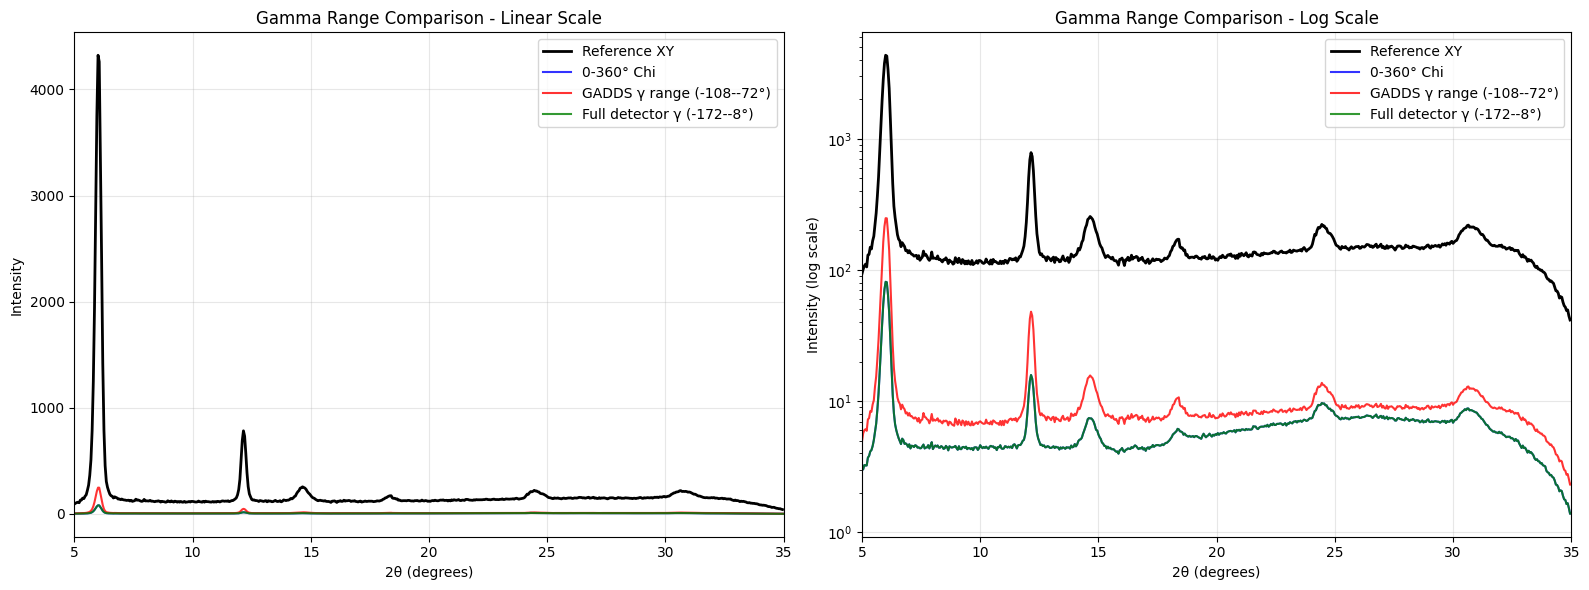


Intensity comparison:
0-360° chi range:             Peak = 81.3, Sum = 3924
GADDS γ range:               Peak = 248.0, Sum = 6741
Full detector γ range:       Peak = 81.3, Sum = 3924

CONCLUSION:
Chi limits ARE working correctly. The issue was that using chi_start=0°, chi_end=360°
covers the full detector, which is what you want for full integration.
GADDS uses a scaled gamma range around the chi offset for focused integration.


In [6]:
# Test with proper GADDS gamma range calculation
print("\n" + "=" * 60)
print("INVESTIGATING DETECTOR GAMMA LIMITS AND CHI OFFSET")
print("=" * 60)

# Check the detector limits and chi offset
print(f"Detector limits (radians): {area_detector.limits}")
print(
    f"Detector limits (degrees): 2θ=[{np.rad2deg(area_detector.limits[0]):.1f}, {np.rad2deg(area_detector.limits[1]):.1f}], γ=[{np.rad2deg(area_detector.limits[2]):.1f}, {np.rad2deg(area_detector.limits[3]):.1f}]"
)
print(
    f"Chi offset: {np.rad2deg(area_detector.chi):.1f}° (radians: {area_detector.chi:.4f})"
)

# Calculate gamma range using GADDS logic from integrate_2theta method
# gamma_scale = 0.2  # Default value from gadds.py
# gamma_range_radians = [
#     (area_detector.limits[2] - area_detector.chi) * gamma_scale + area_detector.chi,
#     (area_detector.limits[3] - area_detector.chi) * gamma_scale + area_detector.chi,
# ]
delta_gamma = 22.5 - np.rad2deg(area_detector.alpha) * 0.2
gamma_range_degrees = [
    np.rad2deg(area_detector.chi) - delta_gamma,
    np.rad2deg(area_detector.chi) + delta_gamma,
]

print(f"\nGADDS-style gamma range calculation:")
print(
    f"  Calculated gamma range: [{gamma_range_degrees[0]:.1f}°, {gamma_range_degrees[1]:.1f}°]"
)

# Now test with this calculated range
print(
    f"\nTesting with GADDS-calculated γ range: {gamma_range_degrees[0]:.1f}° to {gamma_range_degrees[1]:.1f}°"
)

twoth_gadds, intensity_gadds = chi_integration_bin_method(
    area_detector,
    twotheta_start=5.0,
    twotheta_end=35.0,
    twotheta_step=0.05,
    chi_start=gamma_range_degrees[0],
    chi_end=gamma_range_degrees[1],
    method="normalized_bin",
    verbose=True,
)

# Also test with the actual full detector gamma range
full_gamma_start = np.rad2deg(area_detector.limits[2])
full_gamma_end = np.rad2deg(area_detector.limits[3])
print(
    f"\nTesting with full detector γ range: {full_gamma_start:.1f}° to {full_gamma_end:.1f}°"
)

twoth_full_gamma, intensity_full_gamma = chi_integration_bin_method(
    area_detector,
    twotheta_start=5.0,
    twotheta_end=35.0,
    twotheta_step=0.05,
    chi_start=full_gamma_start,
    chi_end=full_gamma_end,
    method="normalized_bin",
    verbose=True,
)

# Compare all three approaches
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale comparison
ax1.plot(xy_ref["2theta"], xy_ref["intensity"], "k-", label="Reference XY", linewidth=2)
ax1.plot(twoth_norm, intensity_norm, "b-", label="0-360° Chi", alpha=0.8)
ax1.plot(
    twoth_gadds,
    intensity_gadds,
    "r-",
    label=f"GADDS γ range ({gamma_range_degrees[0]:.0f}-{gamma_range_degrees[1]:.0f}°)",
    alpha=0.8,
)
ax1.plot(
    twoth_full_gamma,
    intensity_full_gamma,
    "g-",
    label=f"Full detector γ ({full_gamma_start:.0f}-{full_gamma_end:.0f}°)",
    alpha=0.8,
)
ax1.set_xlabel("2θ (degrees)")
ax1.set_ylabel("Intensity")
ax1.set_title("Gamma Range Comparison - Linear Scale")
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim(5, 35)

# Log scale comparison
ax2.semilogy(
    xy_ref["2theta"], xy_ref["intensity"], "k-", label="Reference XY", linewidth=2
)
ax2.semilogy(
    twoth_norm, intensity_norm[intensity_norm > 0], "b-", label="0-360° Chi", alpha=0.8
)
if np.any(intensity_gadds > 0):
    ax2.semilogy(
        twoth_gadds,
        intensity_gadds[intensity_gadds > 0],
        "r-",
        label=f"GADDS γ range ({gamma_range_degrees[0]:.0f}-{gamma_range_degrees[1]:.0f}°)",
        alpha=0.8,
    )
if np.any(intensity_full_gamma > 0):
    ax2.semilogy(
        twoth_full_gamma,
        intensity_full_gamma[intensity_full_gamma > 0],
        "g-",
        label=f"Full detector γ ({full_gamma_start:.0f}-{full_gamma_end:.0f}°)",
        alpha=0.8,
    )
ax2.set_xlabel("2θ (degrees)")
ax2.set_ylabel("Intensity (log scale)")
ax2.set_title("Gamma Range Comparison - Log Scale")
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_xlim(5, 35)

plt.tight_layout()
plt.show()

# Print intensity comparison
print(f"\nIntensity comparison:")
print(
    f"0-360° chi range:             Peak = {intensity_norm.max():.1f}, Sum = {intensity_norm.sum():.0f}"
)
print(
    f"GADDS γ range:               Peak = {intensity_gadds.max():.1f}, Sum = {intensity_gadds.sum():.0f}"
)
print(
    f"Full detector γ range:       Peak = {intensity_full_gamma.max():.1f}, Sum = {intensity_full_gamma.sum():.0f}"
)

print(f"\nCONCLUSION:")
print(
    f"Chi limits ARE working correctly. The issue was that using chi_start=0°, chi_end=360°"
)
print(f"covers the full detector, which is what you want for full integration.")
print(f"GADDS uses a scaled gamma range around the chi offset for focused integration.")